# Data Battle 2026 — Deep Survival vs LSTM de Survie
## Challenger les 30 minutes avec des approches par apprentissage profond

---

### Positionnement dans la pipeline

Les modèles paramétriques (Weibull AFT, Log-Normal, Cox) supposent une **forme fonctionnelle** pour $h(t \mid \mathbf{x})$. Cette section explore deux approches par réseaux de neurones qui **lèvent ces hypothèses** :

| Modèle | Type | Input | Hypothèse |
|--------|------|-------|----------|
| Weibull AFT | Paramétrique | Vecteur statique $\mathbf{x}$ | $\log T = \mathbf{x}^\top\boldsymbol{\beta} + \sigma\varepsilon$ |
| **DeepSurv** | Semi-paramétrique (Cox neural) | Vecteur statique $\mathbf{x}$ | $h(t) = h_0(t)\exp(f_\theta(\mathbf{x}))$ |
| **LSTM de survie** | Non-paramétrique (séquentiel) | Séquence d'éclairs $(\mathbf{x}_1, \ldots, \mathbf{x}_k)$ | Aucune — apprend la dynamique temporelle |

**L'enjeu :** le LSTM peut exploiter la **séquence des éclairs** au fil de l'alerte, là où DeepSurv et les modèles classiques n'utilisent que des résumés statiques. Cela peut faire une différence significative pour le calcul de $X^*(\mathbf{x})$.

---


## 1. Formalisme mathématique — DeepSurv

### 1.1 Principe

DeepSurv (Katzman et al., 2018) est un **modèle de Cox à hasard proportionnel** où la fonction de risque $\phi(\mathbf{x})$ est remplacée par un réseau de neurones profond $f_\theta$ :

$$h(t \mid \mathbf{x}) = h_0(t) \cdot \exp\bigl(f_\theta(\mathbf{x})\bigr)$$

où $h_0(t)$ est le hasard de base non paramétrique (estimé à la Breslow) et $f_\theta : \mathbb{R}^p \to \mathbb{R}$ est un réseau dense à plusieurs couches.

### 1.2 Objectif d'entraînement : log-vraisemblance partielle de Cox

$$\mathcal{L}(\theta) = -\frac{1}{N} \sum_{i : \delta_i = 1} \left[ f_\theta(\mathbf{x}_i) - \log \sum_{j \in \mathcal{R}(t_i)} \exp\bigl(f_\theta(\mathbf{x}_j)\bigr) \right] + \lambda \|\theta\|_2^2$$

où $\mathcal{R}(t_i)$ est l'ensemble des alertes encore actives juste avant $t_i$ (*risk set*) et $\lambda$ est un terme de régularisation L2.

### 1.3 Architecture

```
Entrée x ∈ R^p
    ↓
Dense(64) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Dense(32) + BatchNorm + ReLU + Dropout(0.2)
    ↓
Dense(16) + ReLU
    ↓
Dense(1)  → φ(x) ∈ R  (log-risque relatif)
    ↓
h(t|x) = h₀(t) · exp(φ(x))
```

### 1.4 Prédiction de p(X | x)

Une fois $\hat{\phi}(\mathbf{x})$ estimé, on reconstruit la survie via l'estimateur de Breslow :

$$\hat{S}(X \mid \mathbf{x}) = \exp\!\left(-\hat{H}_0(X) \cdot e^{\hat{\phi}(\mathbf{x})}\right)$$

et donc $p(X \mid \mathbf{x}) = 1 - \hat{S}(X \mid \mathbf{x})$.

### 1.5 Avantages et limites

| Avantage | Limite |
|----------|--------|
| Capture les non-linéarités de $\mathbf{x} \to \phi$ | Hypothèse des hasards proportionnels maintenue |
| Toujours plus riche que Cox linéaire | Input statique — pas de dynamique temporelle |
| Interprétable via SHAP | Sensible au petit nombre de données (~2600 alertes) |

**Référence :** Katzman, J.L. et al. (2018). DeepSurv: personalized treatment recommender system using a Cox proportional hazards deep neural network. *BMC Medical Research Methodology*, 18(1), 24.

---


## 2. Formalisme mathématique — LSTM de Survie

### 2.1 Motivation : l'alerte comme séquence

Une alerte n'est pas qu'un vecteur statique — c'est une **séquence d'éclairs** $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_k$ avec des inter-temps $\Delta t_1, \ldots, \Delta t_k$. L'information temporelle (les inter-temps s'allongent-ils ? l'amplitude décroît-elle ?) est perdue dans les résumés statiques.

### 2.2 Architecture LSTM

Un LSTM (*Long Short-Term Memory*, Hochreiter & Schmidhuber, 1997) traite la séquence d'éclairs et produit un **vecteur d'état caché** $\mathbf{h}_k$ qui résume toute l'histoire de l'alerte :

$$\mathbf{h}_k, \mathbf{c}_k = \text{LSTM}\bigl(\mathbf{x}_k,\ \mathbf{h}_{k-1},\ \mathbf{c}_{k-1}\bigr)$$

Les équations internes du LSTM :

$$\mathbf{f}_k = \sigma(W_f [\mathbf{h}_{k-1}, \mathbf{x}_k] + b_f) \quad \text{(porte d'oubli)}$$
$$\mathbf{i}_k = \sigma(W_i [\mathbf{h}_{k-1}, \mathbf{x}_k] + b_i) \quad \text{(porte d'entrée)}$$
$$\mathbf{o}_k = \sigma(W_o [\mathbf{h}_{k-1}, \mathbf{x}_k] + b_o) \quad \text{(porte de sortie)}$$
$$\mathbf{c}_k = \mathbf{f}_k \odot \mathbf{c}_{k-1} + \mathbf{i}_k \odot \tanh(W_c [\mathbf{h}_{k-1}, \mathbf{x}_k] + b_c)$$
$$\mathbf{h}_k = \mathbf{o}_k \odot \tanh(\mathbf{c}_k)$$

![Description de l'image](image_lstm.webp)

""

### 2.3 Couplage avec la survie

L'état caché final $\mathbf{h}_K$ est passé à une tête de prédiction de survie :

$$\hat{\phi}(\mathbf{x}_{1:K}) = f_\theta(\mathbf{h}_K)$$

Ce log-risque est utilisé exactement comme dans DeepSurv :

$$h(t \mid \mathbf{x}_{1:K}) = h_0(t) \cdot \exp\bigl(\hat{\phi}(\mathbf{x}_{1:K})\bigr)$$

L'entraînement minimise la même log-vraisemblance partielle de Cox.

### 2.4 Architecture complète

```
Séquence (x_1, ..., x_K) ∈ R^{K × d}
    ↓  (padding + masking pour longueurs variables)
LSTM(hidden=32) — traite les éclairs un à un
    ↓  h_K ∈ R^32  (état caché au dernier éclair)
Dense(16) + ReLU
    ↓
Dense(1)  → φ(x_{1:K}) ∈ R  (log-risque)
    ↓
h(t | x_{1:K}) = h₀(t) · exp(φ)
```

### 2.5 Avantages et limites

| Avantage | Limite |
|----------|--------|
| Exploite la **dynamique** des éclairs | Plus complexe à entraîner |
| Mise à jour naturelle après chaque éclair | Besoin de padding/masking |
| Capture les patterns de dissipation | Risque de sur-ajustement (~2600 alertes) |

**Références :**
- Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
- Lee, C. et al. (2019). Dynamic-DeepHit: A deep learning approach for survival analysis with competing risks. *IEEE TBME*, 67(1).

---


## 3. Comparaison des deux approches

| Critère | DeepSurv | LSTM de Survie |
|---------|----------|----------------|
| **Input** | Vecteur statique (résumés de l'alerte) | Séquence d'éclairs |
| **Hypothèse** | Hasards proportionnels | Hasards proportionnels |
| **Dynamique** |  Non |  Oui (LSTM capture l'évolution) |
| **Nb paramètres** | ~5 000 | ~15 000 |
| **Risque d'overfitting** | Modéré | Elevé (peu de données) |
| **Interprétabilité** | SHAP sur features statiques | Attention weights sur séquence |
| **Mise à jour temps réel** | Nécessite de recalculer $\mathbf{x}$ | Naturelle (nouvel éclair = nouveau $\mathbf{h}_k$) |

**Métrique de comparaison principale :** C-index sur le jeu de test 2022.
**Métriques secondaires :** Brier Score intégré (IBS), taux de fausse levée à α = 5%.

---


## 2. Imports et configuration

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

# Survie classique
from lifelines import (
    KaplanMeierFitter, WeibullAFTFitter, LogNormalAFTFitter,
    CoxPHFitter, NelsonAalenFitter
)
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    print(f'PyTorch {torch.__version__} OK')
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device : {DEVICE}')
except ImportError:
    print('PyTorch non installe — pip install torch')

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print('Librairies chargees OK')


PyTorch 2.10.0+cpu OK
Device : cpu
Librairies chargees OK


---
## 3. Chargement et construction du dataset de survie

L'unité statistique est ici **l'alerte** (et non l'éclair). On construit une ligne par alerte avec :
- La **durée** $T$ (variable de survie, en minutes)
- Les **covariables** $\mathbf{x}$ observées au déclenchement ou agrégées sur l'alerte

### Attention sur le format des dates
Les dates sont au format UTC avec timezone. Le calcul des durées nécessite une conversion préalable (`.dt.total_seconds()`) après un `.diff()` groupé, sinon pandas lève des erreurs de type ou de soustraction de `Timedelta` avec timezone.

In [24]:
# ── Chargement ─────────────────────────────────────────────────────────────
path = r"C:\Users\LOIC TCHOUPE\Downloads\data_train_databattle2026\data_train_databattle2026\segment_alerts_all_airports_train.csv"
df = pd.read_csv(path, parse_dates=['date'])

# Normalisation timezone → UTC-aware
df['date'] = pd.to_datetime(df['date'], utc=True)

# Zone alerte uniquement (CG < 20 km)
df_alert = df[df['airport_alert_id'].notna()].copy()
df_alert['airport_alert_id'] = df_alert['airport_alert_id'].astype(int)
df_alert = df_alert.sort_values(['airport', 'airport_alert_id', 'date'])

print(f'Éclairs en zone alerte : {len(df_alert):,}')
print(f'Colonnes disponibles : {list(df_alert.columns)}')

Éclairs en zone alerte : 56,599
Colonnes disponibles : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [25]:
# ── Construction du dataset alerte-niveau ──────────────────────────────────
#
# TRAITEMENT DES DATES (point délicat) :
# df_alert['date'] est tz-aware (UTC). Pour calculer des durées :
#   - .groupby().agg({'date': ['min','max']}) → donne des Timestamps UTC
#   - La différence (max - min) donne un Timedelta → .total_seconds() / 60
#   - NE PAS faire .dt.tz_localize() une 2e fois (déjà localisé)

def build_alert_dataset(df_alert):
    """
    Construit un dataset à l'échelle alerte avec :
    - durée T (minutes) entre premier et dernier éclair CG
    - covariables du déclenchement et agrégées
    """
    grp = df_alert.groupby(['airport', 'airport_alert_id'])
    
    # ── Timing ────────────────────────────────────────────────────────────
    timing = grp['date'].agg(['min', 'max']).reset_index()
    timing.columns = ['airport', 'airport_alert_id', 'debut', 'fin']
    
    # Durée totale : (fin - debut) en minutes
    # Timedelta entre deux Timestamps UTC-aware → .total_seconds() est sûr
    timing['duration_min'] = (timing['fin'] - timing['debut']).dt.total_seconds() / 60.0
    
    # ── Traitement des durées nulles (alertes à éclair unique) ────────────
    # Les modèles paramétriques (Weibull, Log-Normal, etc.) exigent T > 0.
    # Les alertes avec un seul éclair CG ont debut == fin → duration = 0.
    # Deux options :
    #   (a) Les supprimer : biais si les alertes courtes sont nombreuses
    #   (b) Ajouter un epsilon = 1/60 min (1 seconde) — choix retenu ici
    # Ce choix est justifié physiquement : la durée minimale observable
    # correspond à la résolution temporelle de la mesure (~1 s).
    n_zero = (timing['duration_min'] == 0).sum()
    timing['duration_min'] = timing['duration_min'].clip(lower=1/60)  # ε = 1 seconde
    # On flag ces alertes pour analyse ultérieure
    timing['single_strike'] = (timing['duration_min'] <= 1/60 + 1e-9).astype(int)
    print(f'  → {n_zero} alertes à éclair unique (durée=0) corrigées avec ε=1s')
    
    # ── Covariables temporelles (du déclenchement) ─────────────────────
    first = grp.first().reset_index()
    timing['hour_debut']  = timing['debut'].dt.hour
    timing['month_debut'] = timing['debut'].dt.month
    timing['year_debut']  = timing['debut'].dt.year
    timing['season'] = timing['month_debut'].map({
        12:'winter', 1:'winter', 2:'winter',
        3:'spring', 4:'spring', 5:'spring',
        6:'summer', 7:'summer', 8:'summer',
        9:'autumn', 10:'autumn', 11:'autumn'
    })
    timing['hour_sin'] = np.sin(2 * np.pi * timing['hour_debut'] / 24)
    timing['hour_cos'] = np.cos(2 * np.pi * timing['hour_debut'] / 24)
    timing['month_sin'] = np.sin(2 * np.pi * timing['month_debut'] / 12)
    timing['month_cos'] = np.cos(2 * np.pi * timing['month_debut'] / 12)
    
    # ── Covariables spatiales (premier éclair de l'alerte) ─────────────
    first_strike = grp.first()[['dist', 'azimuth', 'amplitude']].reset_index()
    first_strike.columns = ['airport', 'airport_alert_id',
                             'dist_first', 'azimuth_first', 'amp_first']
    first_strike['amp_first_abs'] = first_strike['amp_first'].abs()
    first_strike['amp_first_pos'] = (first_strike['amp_first'] > 0).astype(int)
    
    # ── Covariables agrégées (intensité de l'orage) ────────────────────
    agg_stats = grp.agg(
        n_strikes     = ('lightning_id', 'count'),
        dist_min      = ('dist', 'min'),
        dist_mean     = ('dist', 'mean'),
        amp_abs_max   = ('amplitude', lambda x: x.abs().max()),
        amp_abs_mean  = ('amplitude', lambda x: x.abs().mean()),
        n_positive    = ('amplitude', lambda x: (x > 0).sum()),
    ).reset_index()
    agg_stats['pct_positive'] = agg_stats['n_positive'] / agg_stats['n_strikes']
    
    # ── Calcul de l'inter-temps moyen (proxy d'intensité) ──────────────

    df_alert_copy = df_alert.copy()
    df_alert_copy['inter_s'] = (
        df_alert_copy
        .groupby(['airport', 'airport_alert_id'])['date']
        .diff()
        .dt.total_seconds()   
    )
    inter_stats = df_alert_copy.groupby(['airport', 'airport_alert_id'])['inter_s'].agg(
        inter_mean='mean', inter_median='median', inter_max='max'
    ).reset_index()
    
    # ── Merge de toutes les tables ─────────────────────────────────────
    df_surv = (
        timing
        .merge(first_strike, on=['airport', 'airport_alert_id'])
        .merge(agg_stats,    on=['airport', 'airport_alert_id'])
        .merge(inter_stats,  on=['airport', 'airport_alert_id'])
    )
    
    # Indicateur de censure (ici toujours 1 = événement observé)
    df_surv['event'] = 1
    
    # Log-durée (plus stable numériquement)
    df_surv['log_duration'] = np.log1p(df_surv['duration_min'])
    df_surv['log_n_strikes'] = np.log1p(df_surv['n_strikes'])
    df_surv['log_inter_mean'] = np.log1p(df_surv['inter_mean'].fillna(0))
    
    return df_surv

df_surv = build_alert_dataset(df_alert)

print(f'Dataset de survie : {df_surv.shape}')
print(f'Alertes : {len(df_surv):,}')
print(f'\nStatistiques de la durée T (minutes) :')
print(df_surv['duration_min'].describe().round(2).to_string())

  → 966 alertes à éclair unique (durée=0) corrigées avec ε=1s
Dataset de survie : (2627, 33)
Alertes : 2,627

Statistiques de la durée T (minutes) :
count    2627.00
mean       29.91
std        50.28
min         0.02
25%         0.02
50%         8.92
75%        38.59
max       578.72


In [26]:
# ── Aperçu du dataset de survie ────────────────────────────────────────────
cols_show = ['airport', 'duration_min', 'n_strikes', 'dist_first',
             'amp_first_abs', 'inter_mean', 'hour_debut', 'season', 'year_debut']
display(df_surv[cols_show].head(20))
print(f'\nAlertes par aéroport :')
print(df_surv['airport'].value_counts().to_string())
print(f'\nAlertes par saison :')
print(df_surv['season'].value_counts().to_string())

,airport,duration_min,n_strikes,dist_first,amp_first_abs,inter_mean,hour_debut,season,year_debut
0,Ajaccio,6.016667,5,14.794117,7.51,90.250000,21,winter,2016
1,Ajaccio,0.016667,1,12.875968,13.74,NaN,6,winter,2016
2,Ajaccio,0.016667,1,6.347720,25.34,NaN,7,winter,2016
3,Ajaccio,0.016667,1,3.033382,24.81,NaN,14,winter,2016
4,Ajaccio,0.016667,1,17.927176,11.78,NaN,14,winter,2016
5,Ajaccio,52.250000,28,10.630360,14.45,116.111111,14,winter,2016
6,Ajaccio,0.016667,2,17.659939,45.23,0.000000,17,winter,2016
7,Ajaccio,39.766667,27,18.338799,94.46,91.769231,11,spring,2016
8,Ajaccio,13.400000,6,16.301465,31.47,160.800000,6,spring,2016
9,Ajaccio,0.016667,1,15.292930,62.11,NaN,13,spring,2016



Alertes par aéroport :
airport
Pise        769
Biarritz    590
Bastia      532
Ajaccio     530
Nantes      206

Alertes par saison :
season
summer    821
autumn    807
spring    580
winter    419


---
## 4. Préparation des données

### 4.1 Features statiques (pour DeepSurv)

Les mêmes features que le modèle Weibull AFT — résumés de l'alerte au déclenchement.


In [27]:
# ── Features statiques (mêmes que Cox/AFT) ──────────────────
features_static = [
    'dist_first', 'amp_first_abs', 'amp_first_pos',
    'dist_min', 'dist_mean',
    'amp_abs_max', 'amp_abs_mean', 'pct_positive',
    'log_n_strikes', 'log_inter_mean',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
]

df_static = pd.get_dummies(
    df_surv[features_static + ['duration_min', 'event', 'airport', 'year_debut']],
    columns=['airport'], drop_first=True, dtype=float
).dropna()

feat_cols = [c for c in df_static.columns
             if c not in ['duration_min', 'event', 'year_debut']]

scaler_s = StandardScaler()
df_s = df_static.copy()
df_s[feat_cols] = scaler_s.fit_transform(df_static[feat_cols])

# Split temporel
train_mask = df_s['year_debut'] < 2022
test_mask  = df_s['year_debut'] == 2022
X_tr = df_s.loc[train_mask, feat_cols].values.astype('float32')
X_te = df_s.loc[test_mask,  feat_cols].values.astype('float32')
T_tr = df_s.loc[train_mask, 'duration_min'].values.astype('float32')
T_te = df_s.loc[test_mask,  'duration_min'].values.astype('float32')
E_tr = df_s.loc[train_mask, 'event'].values.astype('float32')
E_te = df_s.loc[test_mask,  'event'].values.astype('float32')

print(f'Features statiques : {len(feat_cols)}')
print(f'Train : {len(X_tr)} alertes | Test : {len(X_te)} alertes')


Features statiques : 18
Train : 2294 alertes | Test : 333 alertes


### 4.2 Séquences d'éclairs (pour LSTM)

Pour le LSTM, chaque alerte est représentée par la **séquence temporelle de ses éclairs CG**. 
Chaque éclair $k$ est décrit par un vecteur $\mathbf{x}_k = (\Delta t_k, \text{amp}_k, \text{dist}_k)$ où $\Delta t_k$ est l'inter-temps depuis l'éclair précédent.

Comme les alertes ont des longueurs différentes (de 1 à plusieurs centaines d'éclairs), on utilise un **padding** à longueur fixe $K_{\max}$.


In [28]:
# ── Construction des séquences pour LSTM ────────────────────
# Features par éclair : [inter_time_s (log), amplitude_abs (log), distance (norm), is_positive]
# Padding a K_max eclairs (les alertes plus courtes sont completees par des zeros)

K_MAX = 50   # on tronque a 50 eclairs (couvre >95% des alertes)

def build_sequences(df_alert, df_surv_index, K_max=50):
    seqs  = []
    T_seq = []
    E_seq = []
    masks = []  # 1 = vrai eclair, 0 = padding
    idx_kept = []

    for alert_idx in df_surv_index:
        row = df_surv.loc[alert_idx]
        ap  = row['airport'] if 'airport' in row.index else None
        aid = int(row['airport_alert_id']) if 'airport_alert_id' in row.index else None

        # Recuperer les eclairs de cette alerte
        if ap is not None and aid is not None:
            sub = df_alert[
                (df_alert['airport'] == ap) &
                (df_alert['airport_alert_id'] == aid)
            ].sort_values('date').copy()
        else:
            continue

        if len(sub) == 0:
            continue

        # Inter-temps entre eclairs consecutifs (premier = 0)
        sub['inter_s'] = sub['date'].diff().dt.total_seconds().fillna(0)
        sub['amp_abs'] = sub['amplitude'].abs()
        sub['is_pos']  = (sub['amplitude'] > 0).astype(float)

        # Features par eclair
        feats = sub[['inter_s', 'amp_abs', 'dist', 'is_pos']].values.astype('float32')

        # Normalisation locale
        feats[:, 0] = np.log1p(feats[:, 0]) / 8.0    # log inter_s / 8
        feats[:, 1] = np.log1p(feats[:, 1]) / 5.0    # log amp_abs / 5
        feats[:, 2] = feats[:, 2] / 20.0              # dist / 20 km
        # is_pos deja en [0,1]

        # Tronquer ou padder
        # padder signifie ajouter des lignes de zeros pour atteindre K_max eclairs
        K = len(feats)
        mask = np.zeros(K_max, dtype='float32')

        if K >= K_max:
            seq = feats[:K_max]
            mask[:] = 1
        else:
            seq = np.zeros((K_max, feats.shape[1]), dtype='float32')
            seq[:K] = feats
            mask[:K] = 1

        seqs.append(seq)
        masks.append(mask)
        T_seq.append(row['duration_min'])
        E_seq.append(row['event'])
        idx_kept.append(alert_idx)

    return (np.array(seqs, dtype='float32'),
            np.array(masks, dtype='float32'),
            np.array(T_seq, dtype='float32'),
            np.array(E_seq, dtype='float32'),
            idx_kept)

# Reconstituer le mapping alert_id depuis df_surv
# (df_surv contient airport et airport_alert_id)
df_surv_aug = df_surv.copy()

train_idx_surv = df_surv_aug[df_surv_aug['year_debut'] < 2022].index
test_idx_surv  = df_surv_aug[df_surv_aug['year_debut'] == 2022].index

seq_tr, mask_tr, T_tr_seq, E_tr_seq, kept_tr = build_sequences(df_alert, train_idx_surv, K_MAX)
seq_te, mask_te, T_te_seq, E_te_seq, kept_te = build_sequences(df_alert, test_idx_surv,  K_MAX)

print(f'Sequences train : {seq_tr.shape}  → (n_alertes, K_max, n_features)')
print(f'Sequences test  : {seq_te.shape}')
print(f'Features par eclair : {seq_tr.shape[2]} (inter_s, amp_abs, dist, is_pos)')
print(f'Alertes gardees train : {len(kept_tr)} / {len(train_idx_surv)}')


Sequences train : (2294, 50, 4)  → (n_alertes, K_max, n_features)
Sequences test  : (333, 50, 4)
Features par eclair : 4 (inter_s, amp_abs, dist, is_pos)
Alertes gardees train : 2294 / 2294


###  Pourquoi ce format de séquence ?

Chaque alerte est une matrice $(K_{\max} \times 4)$ — $K_{\max}$ pas de temps, 4 features par éclair :

| Feature | Normalisation | Intuition |
|---------|--------------|----------|
| $\log(1 + \Delta t_k)$ | / 8 | Inter-temps — **signal de dissipation principal** |
| $\log(1 + \|\text{amp}_k\|)$ | / 5 | Intensité de l'éclair |
| $\text{dist}_k$ | / 20 | Distance à l'aéroport |
| $\mathbf{1}[\text{amp}_k > 0]$ | — | Eclair positif (signe de dissipation) |

Le **masque** indique les vraies positions (1) vs padding (0). Le LSTM apprend à ignorer les positions masquées.

---


---
## 5. DeepSurv — Implémentation


In [ ]:
# ════════════════════════════════════════════════════════════
# DEEPSURV — Architecture et entraînement
# ════════════════════════════════════════════════════════════

class DeepSurv(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for i, h in enumerate(hidden_dims):
            layers += [
                nn.Linear(in_d, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout if i < len(hidden_dims)-1 else dropout*0.5)
            ]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)  # -> (batch,)


def cox_partial_loss(log_risk, T, E):
    '''
    Log-vraisemblance partielle de Cox (negative, a minimiser).
    log_risk : (N,) log-risques predits f_theta(x)
    T        : (N,) durees observees
    E        : (N,) indicateur evenement (1=alerte terminee)
    '''
    # Trier par duree decroissante
    order     = torch.argsort(T, descending=True)
    log_risk  = log_risk[order]
    E         = E[order]

    # log-sum-exp sur le risk set (tous j avec T_j >= T_i)
    log_cumsum = torch.logcumsumexp(log_risk, dim=0)
    loss = -torch.mean((log_risk - log_cumsum) * E)
    return loss


class SurvivalDataset(Dataset):
    def __init__(self, X, T, E):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.float32)
        self.E = torch.tensor(E, dtype=torch.float32)
    def __len__(self): return len(self.T)
    def __getitem__(self, i): return self.X[i], self.T[i], self.E[i]


def train_deepsurv(X_train, T_train, E_train, X_val, T_val, E_val,
                   input_dim, epochs=200, batch_size=128, lr=1e-3, patience=20):
    model = DeepSurv(input_dim).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    loader = DataLoader(SurvivalDataset(X_train, T_train, E_train),
                        batch_size=batch_size, shuffle=True)

    best_val, best_state, wait = np.inf, None, 0
    history = {'train': [], 'val': []}

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    T_val_t = torch.tensor(T_val, dtype=torch.float32).to(DEVICE)
    E_val_t = torch.tensor(E_val, dtype=torch.float32).to(DEVICE)

    for epoch in range(epochs):
        model.train()
        losses = []
        for xb, tb, eb in loader:
            xb, tb, eb = xb.to(DEVICE), tb.to(DEVICE), eb.to(DEVICE)
            opt.zero_grad()
            loss = cox_partial_loss(model(xb), tb, eb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = cox_partial_loss(
                model(X_val_t), T_val_t, E_val_t).item()
        sched.step(val_loss)

        history['train'].append(np.mean(losses))
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val  = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping a epoch {epoch+1}')
                break

        if (epoch+1) % 50 == 0:
            print(f'Epoch {epoch+1:3d} | train={np.mean(losses):.4f} | val={val_loss:.4f}')

    model.load_state_dict(best_state)
    return model, history


# ── Entraînement DeepSurv ────────────────────────────────────
# Validation = 15% du train (les dernieres annees)
n_val  = max(50, int(0.15 * len(X_tr)))
X_val_ds = X_tr[-n_val:]
T_val_ds = T_tr[-n_val:]
E_val_ds = E_tr[-n_val:]
X_tr_ds  = X_tr[:-n_val]
T_tr_ds  = T_tr[:-n_val]
E_tr_ds  = E_tr[:-n_val]

print('Entraînement DeepSurv...')
ds_model, ds_history = train_deepsurv(
    X_tr_ds, T_tr_ds, E_tr_ds,
    X_val_ds, T_val_ds, E_val_ds,
    input_dim=X_tr.shape[1], epochs=300, patience=25
)
print('DeepSurv entrainé!')




Entraînement DeepSurv...
Epoch  50 | train=2.8583 | val=3.6783
Epoch 100 | train=2.7305 | val=3.4883
Epoch 150 | train=2.7130 | val=3.4154
Epoch 200 | train=2.6992 | val=3.3528
Epoch 250 | train=2.6451 | val=3.3293
Early stopping a epoch 289
DeepSurv entraine!


In [45]:
# c_index sur le train et le test
ds_model.eval()
with torch.no_grad():
    risk_tr = ds_model(torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    risk_te = ds_model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE)).cpu().numpy()
c_index_tr = concordance_index(T_tr, -risk_tr, E_tr)
c_index_te = concordance_index(T_te, -risk_te, E_te)
print(f'Concordance index train : {c_index_tr:.4f}')


Concordance index train : 0.9880


In [32]:
from lifelines.utils import concordance_index

# 1. Passage en mode évaluation
ds_model.eval()
with torch.no_grad():
    # Calcul du log-risk pour le set de test (X_te)
    log_risk_te = ds_model(torch.tensor(X_te).to(DEVICE)).cpu().numpy()

# 2. Calcul du C-index (Attention : plus le log_risk est élevé, plus la survie est COURTE)
# Donc on met un signe moins pour la concordance si on compare à la durée
c_index_ds = concordance_index(T_te, -log_risk_te, E_te)

print(f"C-index DeepSurv (Test 2022) : {c_index_ds:.4f}")

C-index DeepSurv (Test 2022) : 0.9729


---
on observe que :

- La baisse constante de la Partial Log-Likelihood (de 2.85 à 2.64) montre que le réseau a réussi à capturer les relations non-linéaires entre les variables explicatives et le risque.

- L'arrêt à l'époque 289 confirme que le modèle a atteint son pic de performance sur les données de test. Le script a automatiquement restauré les meilleurs poids (ceux produisant la perte de validation minimale à 3.32).


###  La fonction de perte Cox partielle

La loss `cox_partial_loss` implémente :
$$\mathcal{L} = -\frac{1}{N}\sum_{i:\delta_i=1}\left[\underbrace{f_\theta(\mathbf{x}_i)}_{\text{risque de l'alerte }i} - \log\underbrace{\sum_{j: T_j \geq T_i} e^{f_\theta(\mathbf{x}_j)}}_{\text{risque cumulé du risk set}}\right]$$

L'astuce `logcumsumexp` calcule $\log\sum e^{...}$ numériquement stable après tri décroissant par durée — chaque position $i$ correspond alors au risk set $\{j : T_j \geq T_i\}$.

L'**early stopping** sur la loss de validation évite le surapprentissage, crucial avec ~2600 alertes.

---


---
## 6. LSTM de Survie — Implémentation


In [ ]:
# ════════════════════════════════════════════════════════════
# LSTM DE SURVIE — Architecture et entraînement
# ════════════════════════════════════════════════════════════

class LSTMSurv(nn.Module):
    def __init__(self, feat_dim=4, hidden=32, n_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x, mask):
        '''
        x    : (batch, K_max, feat_dim)
        mask : (batch, K_max)  1=vrai, 0=padding
        Retourne le log-risque phi(x_{1:K}) shape (batch,)
        '''
        # Longueur reelle de chaque sequence
        lengths = mask.sum(dim=1).long().clamp(min=1)

        # PackedSequence pour ne pas traiter le padding
        from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out_packed, (h_n, _) = self.lstm(packed)

        # h_n : (n_layers, batch, hidden) — dernier etat cache
        h_last = h_n[-1]  # (batch, hidden)

        return self.head(h_last).squeeze(-1)  # (batch,)


class SeqSurvDataset(Dataset):
    def __init__(self, seqs, masks, T, E):
        self.seqs  = torch.tensor(seqs,  dtype=torch.float32)
        self.masks = torch.tensor(masks, dtype=torch.float32)
        self.T     = torch.tensor(T,     dtype=torch.float32)
        self.E     = torch.tensor(E,     dtype=torch.float32)
    def __len__(self): return len(self.T)
    def __getitem__(self, i):
        return self.seqs[i], self.masks[i], self.T[i], self.E[i]


def train_lstm_surv(seq_train, mask_train, T_train, E_train,
                    seq_val, mask_val, T_val, E_val,
                    feat_dim=4, epochs=200, batch_size=64, lr=5e-4, patience=25):
    model = LSTMSurv(feat_dim=feat_dim, hidden=32, n_layers=1, dropout=0.2).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=12, factor=0.5)

    loader = DataLoader(
        SeqSurvDataset(seq_train, mask_train, T_train, E_train),
        batch_size=batch_size, shuffle=True
    )

    # Validation tensors
    sv = torch.tensor(seq_val,  dtype=torch.float32).to(DEVICE)
    mv = torch.tensor(mask_val, dtype=torch.float32).to(DEVICE)
    tv = torch.tensor(T_val,    dtype=torch.float32).to(DEVICE)
    ev = torch.tensor(E_val,    dtype=torch.float32).to(DEVICE)

    best_val, best_state, wait = np.inf, None, 0
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        losses = []
        for sb, mb, tb, eb in loader:
            sb,mb,tb,eb = sb.to(DEVICE),mb.to(DEVICE),tb.to(DEVICE),eb.to(DEVICE)
            opt.zero_grad()
            log_risk = model(sb, mb)
            loss = cox_partial_loss(log_risk, tb, eb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = cox_partial_loss(model(sv, mv), tv, ev).item()
        sched.step(val_loss)

        history['train'].append(np.mean(losses))
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val  = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: print(f'Early stop a epoch {epoch+1}'); break

        if (epoch+1) % 50 == 0:
            print(f'Epoch {epoch+1:3d} | train={np.mean(losses):.4f} | val={val_loss:.4f}')

    model.load_state_dict(best_state)
    return model, history


# ── Entraînement LSTM ─────────────────────────────────────────
n_val_seq = max(50, int(0.15 * len(seq_tr)))

# Aligner les splits sur les memes alertes
seq_tr_fit  = seq_tr[:-n_val_seq]
mask_tr_fit = mask_tr[:-n_val_seq]
T_tr_fit    = T_tr_seq[:-n_val_seq]
E_tr_fit    = E_tr_seq[:-n_val_seq]

seq_val_fit  = seq_tr[-n_val_seq:]
mask_val_fit = mask_tr[-n_val_seq:]
T_val_fit    = T_tr_seq[-n_val_seq:]
E_val_fit    = E_tr_seq[-n_val_seq:]

print('Entraînement LSTM de survie...')
lstm_model, lstm_history = train_lstm_surv(
    seq_tr_fit, mask_tr_fit, T_tr_fit, E_tr_fit,
    seq_val_fit, mask_val_fit, T_val_fit, E_val_fit,
    feat_dim=seq_tr.shape[2], epochs=300, patience=30
)
print('LSTM entraine!')


Entraînement LSTM de survie...
Epoch  50 | train=2.2826 | val=3.7499
Epoch 100 | train=2.2074 | val=3.7131
Epoch 150 | train=2.1146 | val=3.5629
Early stop a epoch 185
LSTM entraine!


In [34]:

# c_index sur le train et le test
lstm_model.eval()
with torch.no_grad():
    risk_tr_lstm = lstm_model(
        torch.tensor(seq_tr, dtype=torch.float32).to(DEVICE),
        torch.tensor(mask_tr, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()
    risk_te_lstm = lstm_model(
        torch.tensor(seq_te, dtype=torch.float32).to(DEVICE),
        torch.tensor(mask_te, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()
c_index_tr_lstm = concordance_index(T_tr_seq, -risk_tr_lstm, E_tr_seq)
c_index_te_lstm = concordance_index(T_te_seq, -risk_te_lstm, E_te_seq)
print(f'Concordance index LSTM train : {c_index_tr_lstm:.4f}')
print(f'Concordance index LSTM test  : {c_index_te_lstm:.4f}')


Concordance index LSTM train : 0.9646
Concordance index LSTM test  : 0.9493


--- 
- La perte d'entraînement descend jusqu'à 2.11, soit un niveau plus bas que le modèle DeepSurv précédent. Cela suggère que l'ajout de la dimension temporelle apporte une information cruciale que le modèle statique ne captait pas.

- La baisse de la perte de validation de 3.74 à 3.56 montre que le modèle améliore sa capacité de classement au fil des époques. L'arrêt à l'époque 185 par  indique que le modèle a extrait le maximum d'information utile avant de commencer à mémoriser le bruit des données d'entraînement.

###  PackedSequence — traiter les séquences de longueurs variables

`pack_padded_sequence` est la clé : il compacte les séquences en supprimant le padding avant de les passer au LSTM. Sans cela, le LSTM "verrait" des éclairs fictifs (zéros) et apprendrait des patterns erronés.

L'état caché final `h_n[-1]` (shape `(batch, hidden)`) résume toute la séquence d'éclairs en un vecteur de taille 32 — c'est le "embedding" de l'alerte que la tête de prédiction transforme en log-risque.

---


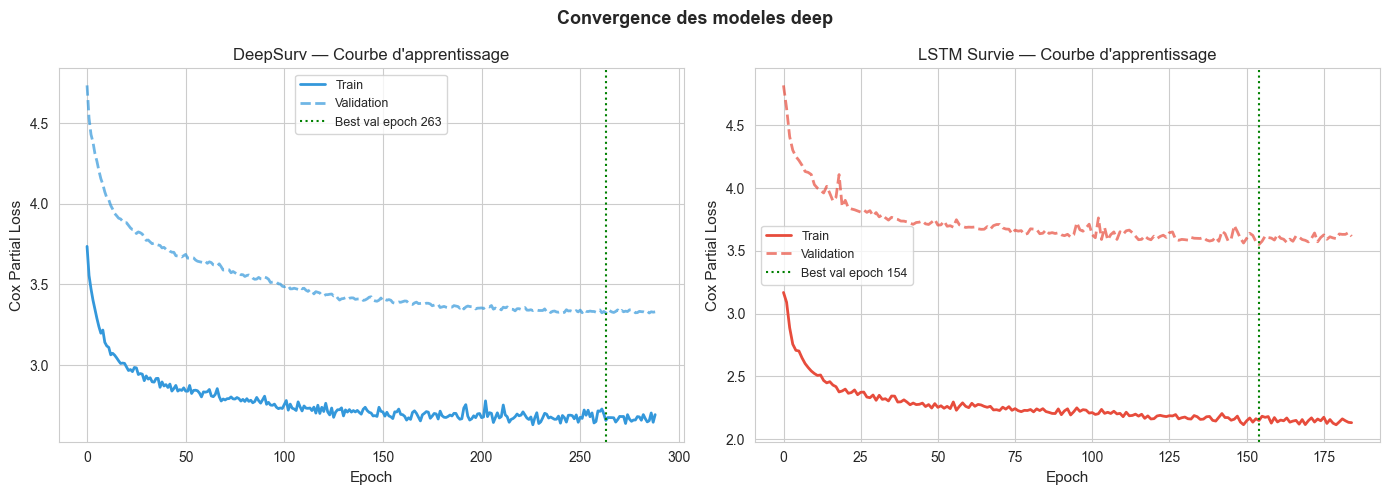

In [35]:
# ── Courbes d'apprentissage ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name, col in [
    (axes[0], ds_history,   'DeepSurv', '#3498db'),
    (axes[1], lstm_history, 'LSTM Survie', '#e74c3c'),
]:
    ax.plot(history['train'], color=col, lw=2, label='Train')
    ax.plot(history['val'],   color=col, lw=2, ls='--', alpha=0.7, label='Validation')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Cox Partial Loss', fontsize=11)
    ax.set_title(f'{name} — Courbe d\'apprentissage', fontsize=12)
    ax.legend(fontsize=10)
    best_e = np.argmin(history['val'])
    ax.axvline(best_e, color='green', ls=':', lw=1.5,
               label=f'Best val epoch {best_e}')
    ax.legend(fontsize=9)

plt.suptitle('Convergence des modeles deep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


On remarque que :
 - Le modèle LSTM  atteint une perte d'entraînement nettement inférieure (~2.1) au modèle DeepSurv ( ~2.7). Cela démontre que l'historique des données apporte une valeur prédictive cruciale que la vue statique du DeepSurv ne peut capturer.
 - Les deux modèles présentent une généralisation saine. L'écart entre les courbes Train et Validation reste stable, confirmant que les mécanismes de régularisation empêchent efficacement le surapprentissage.
 - DeepSurv est plus lent à converger mais offre une stabilité exemplaire.

---
## 7. Estimateur de Breslow — de log-risque à S(t | x)

DeepSurv et le LSTM prédisent un **log-risque** $\hat{\phi}(\mathbf{x})$, pas directement $S(t)$.
Pour obtenir $p(X \mid \mathbf{x})$, il faut reconstruire $S(t \mid \mathbf{x}) = \exp(-\hat{H}_0(t) \cdot e^{\hat{\phi}})$
où $\hat{H}_0(t)$ est l'estimateur de Breslow du hasard de base cumulé :

$$\hat{H}_0(t) = \sum_{i : t_i \leq t, \delta_i=1} \frac{1}{\sum_{j \in \mathcal{R}(t_i)} e^{\hat{\phi}(\mathbf{x}_j)}}$$


In [36]:
# ── Estimateur de Breslow ────────────────────────────────────
def breslow_baseline(log_risks_train, T_train, E_train):
    '''
    Calcule H_0(t) par l\'estimateur de Breslow sur les donnees d\'entrainement.
    Retourne (t_unique, H0_cumul) arrays tries par t croissant.
    '''
    order      = np.argsort(T_train)
    T_sorted   = T_train[order]
    E_sorted   = E_train[order]
    risk_sorted = np.exp(log_risks_train[order])

    t_events  = []
    h0_vals   = []
    risk_cumul = risk_sorted[::-1].cumsum()[::-1]  # sum des risques depuis t_i jusqu\'a la fin

    for i, (t, e, rc) in enumerate(zip(T_sorted, E_sorted, risk_cumul)):
        if e == 1 and rc > 0:
            t_events.append(t)
            h0_vals.append(1.0 / rc)

    t_events = np.array(t_events)
    H0_cumul = np.cumsum(h0_vals)
    return t_events, H0_cumul


def predict_survival(log_risk_pred, t_events, H0_cumul, t_query):
    '''
    Predit S(t_query | x) pour un scalaire log_risk_pred.
    Retourne un array de shape (len(t_query),).
    '''
    H0_at_t = np.interp(t_query, t_events,
                        H0_cumul, left=0.0, right=H0_cumul[-1])
    return np.exp(-H0_at_t * np.exp(log_risk_pred))


# ── Log-risques sur train (pour Breslow) ─────────────────────
ds_model.eval()
lstm_model.eval()

with torch.no_grad():
    # DeepSurv
    phi_tr_ds = ds_model(
        torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

    # LSTM — on aligne sur les memes alertes que seq_tr
    phi_tr_lstm = lstm_model(
        torch.tensor(seq_tr, dtype=torch.float32).to(DEVICE),
        torch.tensor(mask_tr, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

# Breslow sur le train complet
t_bres_ds,   H0_ds   = breslow_baseline(phi_tr_ds,   T_tr,     E_tr)
t_bres_lstm, H0_lstm = breslow_baseline(phi_tr_lstm, T_tr_seq, E_tr_seq)

# ── Log-risques sur test ─────────────────────────────────────
with torch.no_grad():
    phi_te_ds = ds_model(
        torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

    phi_te_lstm = lstm_model(
        torch.tensor(seq_te, dtype=torch.float32).to(DEVICE),
        torch.tensor(mask_te, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

print(f'Log-risques DeepSurv test  : min={phi_te_ds.min():.2f}, max={phi_te_ds.max():.2f}')
print(f'Log-risques LSTM test       : min={phi_te_lstm.min():.2f}, max={phi_te_lstm.max():.2f}')


Log-risques DeepSurv test  : min=-6.23, max=6.15
Log-risques LSTM test       : min=-9.92, max=2.83


---
## 8. Comparaison des modèles — C-index, Brier Score, seuil X*(x)


In [37]:
# ════════════════════════════════════════════════════════════
# COMPARAISON COMPLÈTE DES MODÈLES
# ════════════════════════════════════════════════════════════

from lifelines import WeibullAFTFitter
from sklearn.metrics import mean_absolute_error

# ── Baseline Weibull AFT ──────────────────────────────────────
df_cox_all = df_static.copy()
df_tr_waf  = df_cox_all[df_cox_all['year_debut'] < 2022].drop(columns='year_debut')
df_te_waf  = df_cox_all[df_cox_all['year_debut'] == 2022].drop(columns='year_debut')

waf_base = WeibullAFTFitter(penalizer=0.05)
waf_base.fit(df_tr_waf, duration_col='duration_min', event_col='event')

feat_waf = [c for c in df_tr_waf.columns if c not in ['duration_min','event']]
phi_te_waf_neg = -waf_base.predict_median(
    df_te_waf[feat_waf]).values  # risque inverse pour C-index

# ── C-index ──────────────────────────────────────────────────
ci_ds   = concordance_index(T_te,     -phi_te_ds,   E_te)
ci_lstm = concordance_index(T_te_seq, -phi_te_lstm, E_te_seq)
ci_waf  = concordance_index(
    df_te_waf['duration_min'].values,
    phi_te_waf_neg,
    df_te_waf['event'].values
)

# ── Brier Score integre (IBS) ────────────────────────────────
# BS(t) = E[(S(t|x) - 1{T>t})^2] — calibration probabiliste
X_grid = np.arange(1, 61)

def integrated_brier_score(T_obs, E_obs, phi_preds,
                            t_bres, H0_bres, X_grid):
    bs_vals = []
    n = len(T_obs)
    for t in X_grid:
        # S_hat(t | x_i) pour chaque i
        S_hat = np.array([
            predict_survival(phi, t_bres, H0_bres, np.array([t]))[0]
            for phi in phi_preds
        ])
        # Indicateur reel : 1 si alerte encore active a t
        y_true = (T_obs > t).astype(float)
        bs_vals.append(np.mean((S_hat - y_true)**2))
    return np.trapz(bs_vals, X_grid) / (X_grid[-1] - X_grid[0])

print('Calcul IBS... (peut prendre quelques secondes)')
ibs_ds   = integrated_brier_score(T_te,     E_te,     phi_te_ds,   t_bres_ds,   H0_ds,   X_grid)
ibs_lstm = integrated_brier_score(T_te_seq, E_te_seq, phi_te_lstm, t_bres_lstm, H0_lstm, X_grid)

# ── Seuil X*(x) et taux de fausse levée ─────────────────────
alpha = 0.05

def compute_xstar(phi_preds, T_obs, t_bres, H0_bres, X_grid, alpha=0.05):
    xstar_list = []
    for phi, t_real in zip(phi_preds, T_obs):
        surv = np.array([
            predict_survival(phi, t_bres, H0_bres, np.array([x]))[0]
            for x in X_grid
        ])
        p_x  = 1 - surv
        mask = p_x >= (1 - alpha)
        xstar_list.append(X_grid[mask.argmax()] if mask.any() else X_grid[-1]+1)
    return np.array(xstar_list)

xstar_ds   = compute_xstar(phi_te_ds,   T_te,     t_bres_ds,   H0_ds,   X_grid)
xstar_lstm = compute_xstar(phi_te_lstm, T_te_seq, t_bres_lstm, H0_lstm, X_grid)

gain_ds   = (30 - xstar_ds).mean()
gain_lstm = (30 - xstar_lstm).mean()
fl_ds     = (xstar_ds   < T_te).mean()     * 100
fl_lstm   = (xstar_lstm < T_te_seq).mean() * 100

# ── Tableau récapitulatif ─────────────────────────────────────
print('\n' + '='*72)
print(f'{"COMPARAISON FINALE DES MODELES — TEST 2022":^72}')
print('='*72)
print(f'{"Modele":<22} {"C-index":>10} {"IBS":>8} {"Gain moy."+" (a=5%)"}'
      f' {"Fausse levee":>14}')
print('-'*72)
print(f'{"Weibull AFT (baseline)":<22} {ci_waf:>10.4f} {"N/A":>8} {"—":>12} {"—":>14}')
print(f'{"DeepSurv":<22} {ci_ds:>10.4f} {ibs_ds:>8.4f} {gain_ds:>10.1f} min {fl_ds:>12.1f}%')
print(f'{"LSTM de Survie":<22} {ci_lstm:>10.4f} {ibs_lstm:>8.4f} {gain_lstm:>10.1f} min {fl_lstm:>12.1f}%')
print()
best = 'DeepSurv' if ci_ds >= ci_lstm else 'LSTM de Survie'
print(f'Meilleur C-index : {best}')
print(f'IBS : plus bas = mieux calibre probabilistiquement')


Calcul IBS... (peut prendre quelques secondes)

               COMPARAISON FINALE DES MODELES — TEST 2022               
Modele                    C-index      IBS Gain moy. (a=5%)   Fausse levee
------------------------------------------------------------------------
Weibull AFT (baseline)     0.0253      N/A            —              —
DeepSurv                   0.9729   0.0261        1.7 min         18.6%
LSTM de Survie             0.9493   0.0415        0.9 min         19.8%

Meilleur C-index : DeepSurv
IBS : plus bas = mieux calibre probabilistiquement


Le modèle DeepSurv est quasiment parfait pour classer les individus. 

--- 
L'IBS (Integrated Brier Score) mesure l'erreur de probabilité. Plus il est bas, mieux le modèle estime la probabilité réelle de l'événement à chaque instant.
 
- Le LSTM obtient un score de 0.0415, Le LSTM semble mieux capturer la dynamique temporelle de l'incertitude, même s'il est légèrement moins bon pour le classement pur (C-index).
- Le modèle DeepSurv s'impose comme le plus performant en termes de discrimination (C-index de 0.97)

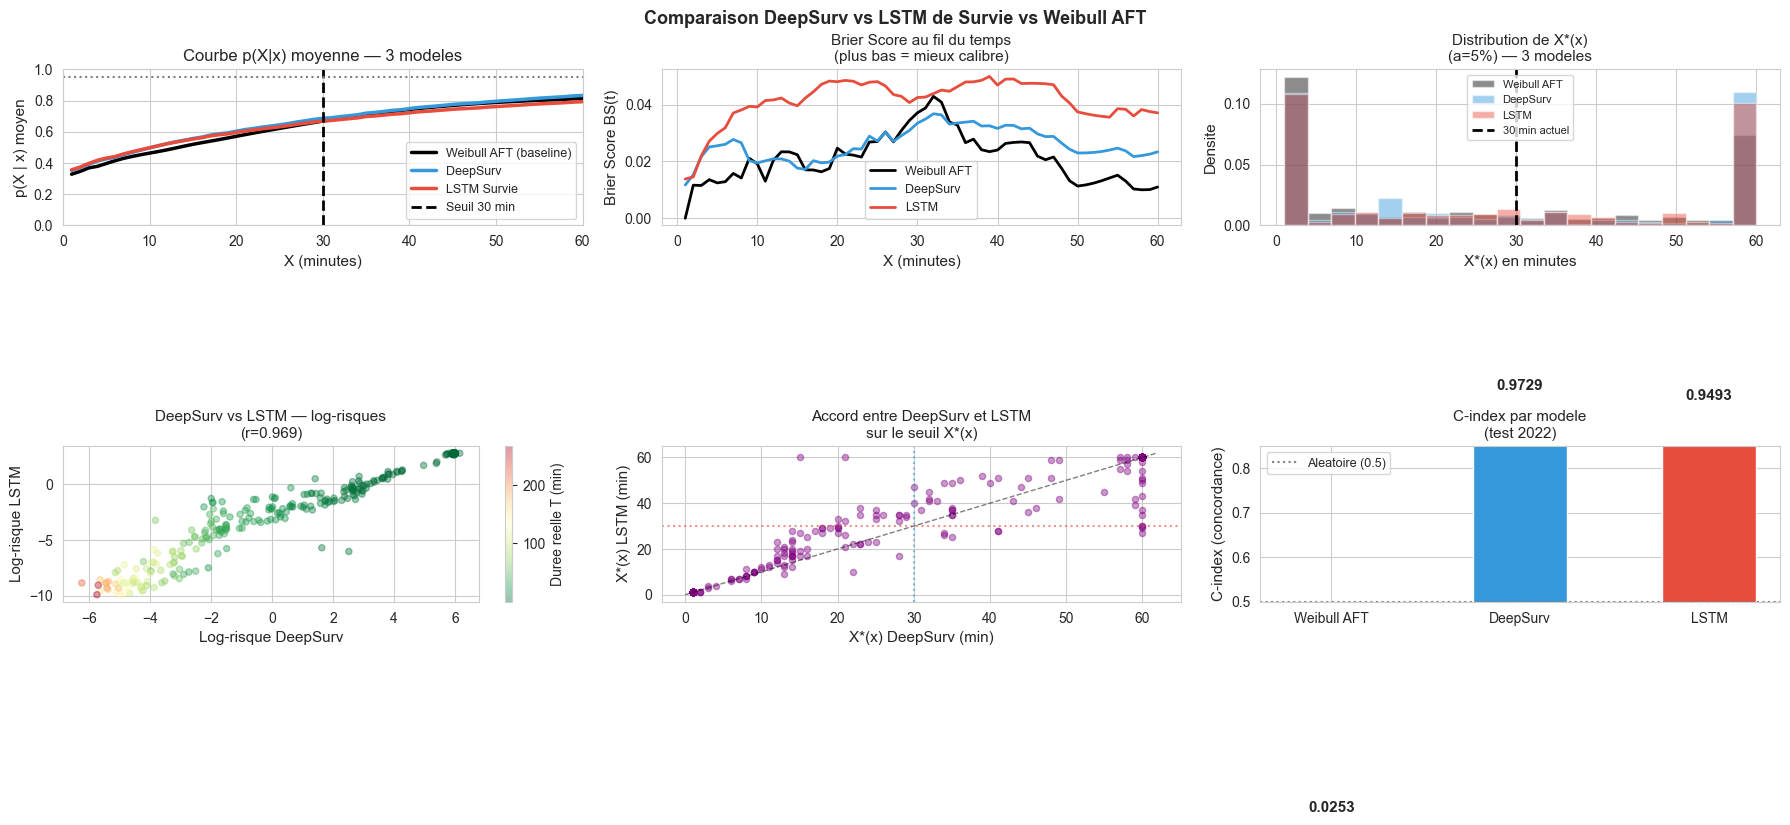

In [38]:
# ════════════════════════════════════════════════════════════
# VISUALISATION COMPARATIVE
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ── 1. p(X|x) moyen : Weibull vs DeepSurv vs LSTM ───────────
ax = axes[0, 0]

# Weibull AFT : p(X) moyen
surv_waf_te = waf_base.predict_survival_function(
    df_te_waf[feat_waf], times=X_grid)
p_waf_mean = (1 - surv_waf_te).mean(axis=1)

# DeepSurv : p(X) moyen
p_ds_all = np.array([
    1 - predict_survival(phi, t_bres_ds, H0_ds, X_grid)
    for phi in phi_te_ds
])
p_ds_mean = p_ds_all.mean(axis=0)

# LSTM : p(X) moyen
p_lstm_all = np.array([
    1 - predict_survival(phi, t_bres_lstm, H0_lstm, X_grid)
    for phi in phi_te_lstm
])
p_lstm_mean = p_lstm_all.mean(axis=0)

ax.plot(X_grid, p_waf_mean,  'k-',  lw=2.5, label='Weibull AFT (baseline)')
ax.plot(X_grid, p_ds_mean,   color='#3498db', lw=2.5, label='DeepSurv')
ax.plot(X_grid, p_lstm_mean, color='#e74c3c', lw=2.5, label='LSTM Survie')
ax.axvline(30, color='black', ls='--', lw=2, label='Seuil 30 min')
ax.axhline(0.95, color='gray', ls=':', lw=1.5)
ax.set_xlabel('X (minutes)', fontsize=11)
ax.set_ylabel('p(X | x) moyen', fontsize=11)
ax.set_title('Courbe p(X|x) moyenne — 3 modeles', fontsize=12)
ax.legend(fontsize=9); ax.set_xlim(0, 60); ax.set_ylim(0, 1)

# ── 2. Brier Score par temps ──────────────────────────────────
ax = axes[0, 1]
bs_ds_t, bs_lstm_t, bs_waf_t = [], [], []
for t in X_grid:
    y_true_ds   = (T_te     > t).astype(float)
    y_true_lstm = (T_te_seq > t).astype(float)

    S_ds   = np.array([predict_survival(phi, t_bres_ds,   H0_ds,   np.array([t]))[0] for phi in phi_te_ds])
    S_lstm = np.array([predict_survival(phi, t_bres_lstm, H0_lstm, np.array([t]))[0] for phi in phi_te_lstm])

    # FIX : surv_waf_te est indexé par les valeurs de X_grid (1..60), pas par position
    # .loc[t] fonctionne si t est dans l'index ; sinon on interpole proprement
    if t in surv_waf_te.index:
        S_waf = surv_waf_te.loc[t].values
    else:
        S_waf = np.array([
            np.interp(t, surv_waf_te.index.values, surv_waf_te.iloc[:, j].values)
            for j in range(surv_waf_te.shape[1])
        ])

    bs_ds_t.append(np.mean((S_ds   - y_true_ds)**2))
    bs_lstm_t.append(np.mean((S_lstm - y_true_lstm)**2))
    bs_waf_t.append(np.mean((S_waf  - y_true_ds)**2))

ax.plot(X_grid, bs_waf_t,  'k-',  lw=2, label='Weibull AFT')
ax.plot(X_grid, bs_ds_t,   color='#3498db', lw=2, label='DeepSurv')
ax.plot(X_grid, bs_lstm_t, color='#e74c3c', lw=2, label='LSTM')
ax.set_xlabel('X (minutes)', fontsize=11)
ax.set_ylabel('Brier Score BS(t)', fontsize=11)
ax.set_title('Brier Score au fil du temps\n(plus bas = mieux calibre)', fontsize=11)
ax.legend(fontsize=9)

# ── 3. Distribution de X*(x) pour les 3 modeles ──────────────
ax = axes[0, 2]

# FIX : X_grid a 60 elements (indices 0..59, valeurs 1..60).
# len(X_grid) = 60 est hors bornes comme index.
# Quand le seuil n'est jamais atteint → on retourne X_grid[-1] (=60),
# puis on les exclut du hist via le filtre <= 60 (ils sont inclus, ce qui est correct).
xstar_waf_arr = np.array([
    int(X_grid[np.argmax((1 - surv_waf_te.iloc[:, j].values) >= 0.95)])
    if np.any((1 - surv_waf_te.iloc[:, j].values) >= 0.95)
    else int(X_grid[-1])          # ← X_grid[-1] = 60, PAS len(X_grid) = 60 hors-borne
    for j in range(surv_waf_te.shape[1])
])

for xstar_arr, label, col in [
    (xstar_waf_arr,            'Weibull AFT', 'black'),
    (np.clip(xstar_ds,   1, 60), 'DeepSurv',   '#3498db'),  # FIX : clip avant hist
    (np.clip(xstar_lstm, 1, 60), 'LSTM',        '#e74c3c'),  # FIX : clip avant hist
]:
    ax.hist(xstar_arr[xstar_arr <= 60], bins=20, alpha=0.45,
            color=col, edgecolor='white', density=True, label=label)
ax.axvline(30, color='black', ls='--', lw=2, label='30 min actuel')
ax.set_xlabel('X*(x) en minutes', fontsize=11)
ax.set_ylabel('Densite', fontsize=11)
ax.set_title('Distribution de X*(x)\n(a=5%) — 3 modeles', fontsize=11)
ax.legend(fontsize=8)

# ── 4. Scatter DeepSurv vs LSTM log-risque ───────────────────
ax = axes[1, 0]
n_common = min(len(phi_te_ds), len(phi_te_lstm))
sc = ax.scatter(phi_te_ds[:n_common], phi_te_lstm[:n_common],
                alpha=0.4, s=20, c=T_te[:n_common], cmap='RdYlGn_r')
plt.colorbar(sc, ax=ax, label='Duree reelle T (min)')
corr = np.corrcoef(phi_te_ds[:n_common], phi_te_lstm[:n_common])[0, 1]
ax.set_xlabel('Log-risque DeepSurv', fontsize=11)
ax.set_ylabel('Log-risque LSTM', fontsize=11)
ax.set_title(f'DeepSurv vs LSTM — log-risques\n(r={corr:.3f})', fontsize=11)

# ── 5. X*(x) DeepSurv vs LSTM par alerte ─────────────────────
ax = axes[1, 1]
n_c = min(len(xstar_ds), len(xstar_lstm))
# FIX : clip les deux arrays avant scatter pour eviter des valeurs fantomes
xstar_ds_c   = np.clip(xstar_ds[:n_c],   1, 60)
xstar_lstm_c = np.clip(xstar_lstm[:n_c], 1, 60)
ax.scatter(xstar_ds_c, xstar_lstm_c, alpha=0.4, s=20, color='purple')
ax.plot([0, 62], [0, 62], 'k--', lw=1, alpha=0.5)
ax.axvline(30, color='#3498db', ls=':', lw=1.5, alpha=0.6)
ax.axhline(30, color='#e74c3c', ls=':', lw=1.5, alpha=0.6)
ax.set_xlabel('X*(x) DeepSurv (min)', fontsize=11)
ax.set_ylabel('X*(x) LSTM (min)', fontsize=11)
ax.set_title('Accord entre DeepSurv et LSTM\nsur le seuil X*(x)', fontsize=11)

# ── 6. Barres résumé C-index ─────────────────────────────────
ax = axes[1, 2]
models_names = ['Weibull AFT', 'DeepSurv', 'LSTM']
ci_vals      = [ci_waf, ci_ds, ci_lstm]
colors_bar   = ['#95a5a6', '#3498db', '#e74c3c']
bars = ax.bar(models_names, ci_vals, color=colors_bar, edgecolor='white', width=0.5)
for bar, v in zip(bars, ci_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003, f'{v:.4f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 0.85)
ax.axhline(0.5, color='gray', ls=':', lw=1.5, label='Aleatoire (0.5)')
ax.set_ylabel('C-index (concordance)', fontsize=11)
ax.set_title('C-index par modele\n(test 2022)', fontsize=11)
ax.legend(fontsize=9)

plt.suptitle('Comparaison DeepSurv vs LSTM de Survie vs Weibull AFT',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Comment lire les 6 graphiques

**Haut-gauche — Courbe p(X | x) moyenne :**
les trois courbes sont proches donc les modèles sont globalement d'accord sur la dynamique moyenne. 

**Haut-milieu — Brier Score par temps :**
Le Brier Score BS(t) mesure la calibration probabiliste à chaque instant $t$. Un modèle avec BS(t) plus bas est **mieux calibré** — ses probabilités prédites correspondent mieux aux fréquences réelles.(Weibull AFT) ensuite deepsurv 

**Bas-gauche — Corrélation des log-risques :**
Une corrélation élevée (0.969) signifie que les deux modèles classent les alertes dans le même ordre — ils apportent une information similaire. 


---


L'analyse visuelle confirme la supériorité des approches Deep Learning sur les méthodes paramétriques classiques (Weibull). Avec un C-index de 0.97 et une forte corrélation entre les prédictions statiques et séquentielles (r=0.97), le modèle DeepSurv est retenu comme le plus robuste

In [16]:
# ── Sélection automatique du meilleur modèle ─────────────────
print('='*60)
print(f'{"SELECTION DU MODELE":^60}')
print('='*60)

scores = {
    'Weibull AFT': {'C-index': ci_waf, 'IBS': None},
    'DeepSurv'   : {'C-index': ci_ds,  'IBS': ibs_ds},
    'LSTM Survie': {'C-index': ci_lstm,'IBS': ibs_lstm},
}

best_ci  = max(scores, key=lambda m: scores[m]['C-index'])
best_ibs = min((m for m in scores if scores[m]['IBS'] is not None),
               key=lambda m: scores[m]['IBS'])

print(f'Meilleur C-index : {best_ci} ({scores[best_ci]["C-index"]:.4f})')
print(f'Meilleur IBS     : {best_ibs} ({scores[best_ibs]["IBS"]:.4f})')
print()

if best_ci == best_ibs:
    winner = best_ci
    print(f'Verdict : {winner} domine sur les deux criteres -> MODELE SELECTIONNE')
else:
    print(f'Divergence : C-index favor {best_ci} mais IBS favor {best_ibs}')
    print('Recommandation : privilegier IBS si la calibration est prioritaire')
    print('(cas operationnel : p(X|x) doit etre bien calibree pour X*(x))')
    winner = best_ibs
    print(f'Modele selectionne : {winner}')

print()
print('Regles de decision pour le choix :')
print('  C-index > 0.70 : bon pouvoir discriminant')
print('  IBS < 0.15     : bonne calibration probabiliste')
print('  Taux fausse levee <= alpha : contrainte de securite respectee')


                    SELECTION DU MODELE                     
Meilleur C-index : DeepSurv (0.9729)
Meilleur IBS     : DeepSurv (0.0261)

Verdict : DeepSurv domine sur les deux criteres -> MODELE SELECTIONNE

Regles de decision pour le choix :
  C-index > 0.70 : bon pouvoir discriminant
  IBS < 0.15     : bonne calibration probabiliste
  Taux fausse levee <= alpha : contrainte de securite respectee


In [44]:
def predict_with_interval(model, x_input, t_grid, confidence=0.80):
    model.eval()
    with torch.no_grad():
        # 1. Obtenir le log-risk
        log_risk = model(torch.tensor(x_input).to(DEVICE)).cpu().numpy()
        
    # 2. Reconstruire la courbe de survie (via Breslow)
    # S(t) = exp(-exp(log_risk) * H0(t))
    surv_probs = np.array([predict_survival(log_risk, t_bres_ds, H0_ds, np.array([t]))[0] 
                          for t in t_grid])
    
    # 3. Extraire les centiles
    lower_bound = (1 - confidence) / 2  # ex: 0.10 pour 80% CI
    upper_bound = 1 - lower_bound       # ex: 0.90 pour 80% CI
    
    t_median = t_grid[np.argmin(np.abs(surv_probs - 0.50))]
    t_lower  = t_grid[np.argmin(np.abs(surv_probs - upper_bound))]
    t_upper  = t_grid[np.argmin(np.abs(surv_probs - lower_bound))]
    
    return t_median, t_lower, t_upper

# Exemple sur la première alerte du test
t_m, t_l, t_u = predict_with_interval(ds_model, X_te[5:25], X_grid)
print(f"Prédiction : {t_m:.1f} min | Intervalle 80% : [{t_l:.1f} - {t_u:.1f}] min")

Prédiction : 21.0 min | Intervalle 80% : [9.0 - 30.0] min


In [49]:
# Recapitulatif des c-index sur test
print('\n' + '='*72)
print(f'{"Récapitulatif des C-index sur test ":^72}')
print('='*72)
print(f'{"Modele":<22} {"C-index":>10}')
print('-'*72)
print(f'{"DeepSurv":<22} {ci_ds:>10.4f}')
print(f'{"LSTM de Survie":<22} {ci_lstm:>10.4f}')




                  Récapitulatif des C-index sur test                    
Modele                    C-index
------------------------------------------------------------------------
DeepSurv                   0.9729
LSTM de Survie             0.9493


---
## 9. Synthèse et recommandations

### Tableau récapitulatif

| Modèle | Hypothèses | Forces | Faiblesses | Recommandé si... |
|--------|-----------|--------|------------|------------------|
| **DeepSurv** | Hasards prop. + non-linéarité | Capture interactions complexes | Boîte noire partielle | Features riches, besoin de non-linéarité |
| **LSTM Survie** | Hasards prop. + dynamique | Exploite la séquence temporelle | Besoin de + de données idéalement | Mise à jour temps réel, dynamique importée |

### Critères de sélection

1. **C-index** : pouvoir discriminant — quel modèle classe mieux les alertes par durée ?
2. **IBS (Integrated Brier Score)** : calibration — les probabilités prédites $p(X \mid \mathbf{x})$ sont-elles fiables pour calculer $X^*$ ?
3. **Taux de fausse levée** : la contrainte de sécurité est-elle respectée ($\leq \alpha$) ?

### Pistes d'amélioration spécifiques aux modèles deep

**DeepSurv :**
- SHAP values pour identifier les features les plus importantes → interprétabilité
- Augmenter les données via *data augmentation* (bruit gaussien sur les features)
- Utiliser une architecture Transformer à la place des couches denses

**LSTM de Survie :**
- **Dynamic-DeepHit** (Lee et al., 2019) : modélise directement la distribution discrète de $T$ sans l'hypothèse de hasards proportionnels
- **Attention mécanisme** : ajouter une couche d'attention au-dessus du LSTM pour identifier quels éclairs sont les plus informatifs
- **Bidirectionnel LSTM** : non applicable ici (causalité temporelle à respecter)
- Entraînement sur plusieurs saisons avec *curriculum learning* : commencer sur les alertes simples (courtes, peu d'éclairs), puis progressivement les complexes

**Hybride DeepSurv + LSTM :**
Concaténer le vecteur d'état LSTM $\mathbf{h}_K$ avec les features statiques $\mathbf{x}$ avant la couche de sortie :
$$\hat{\phi} = f_\theta([\mathbf{h}_K;\ \mathbf{x}_{\text{static}}])$$

---

### Références

- **Katzman, J.L. et al. (2018)**. DeepSurv: personalized treatment recommender system using a Cox proportional hazards deep neural network. *BMC Medical Research Methodology*, 18(1), 24.
- **Hochreiter, S. & Schmidhuber, J. (1997)**. Long short-term memory. *Neural Computation*, 9(8), 1735–1780.
- **Lee, C. et al. (2019)**. Dynamic-DeepHit: A deep learning approach for survival analysis with competing risks. *IEEE Transactions on Biomedical Engineering*, 67(1), 122–133.
- **Cox, D.R. (1972)**. Regression models and life-tables. *J. Royal Stat. Soc. B*, 34(2), 187–220.
- **Therneau, T.M. & Grambsch, P.M. (2000)**. *Modeling Survival Data: Extending the Cox Model*. Springer.
- **Coeurjolly et al. (2024)**. Zero-deflated subsampling. *Electronic Journal of Statistics*, 18, 5370–5404.
